--- General Perceptron Trainer ---
Enter learning rate (press Enter for default 0.1): 
Enter number of epochs (press Enter for default 10): 

--- Dataset Setup ---
How many total samples (rows) are in your dataset? 4
How many features (inputs) per sample? 2

Enter your data row by row.
Enter 2 features for sample 1 (space-separated): 0 0
Enter target label for sample 1 (e.g., 0 or 1): 0
-
Enter 2 features for sample 2 (space-separated): 1 0
Enter target label for sample 2 (e.g., 0 or 1): 0
-
Enter 2 features for sample 3 (space-separated): 0 1
Enter target label for sample 3 (e.g., 0 or 1): 0
-
Enter 2 features for sample 4 (space-separated): 1 1
Enter target label for sample 4 (e.g., 0 or 1): 1
-

Training Perceptron...

--- Final Results ---
Final Weights: w1 = 0.10, w2 = 0.20
Final Bias (b): -0.20


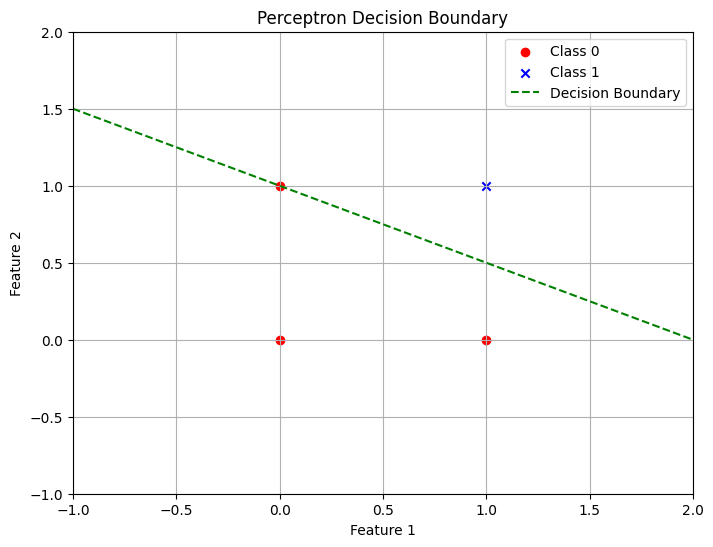

In [1]:
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting

def train_perceptron(X, y, lr=0.1, epochs=10):
    # weights array automatically sizes itself to the number of features (columns in X)
    weights = np.zeros(X.shape[1])
    bias = 0

    for _ in range(epochs):
        for i in range(len(X)):
            # 1. Calculate Linear Combination
            linear_output = np.dot(X[i], weights) + bias

            # 2. Apply Activation Function (Heaviside Step)
            y_pred = 1 if linear_output >= 0 else 0

            # 3. Compute Update (Error * Learning Rate)
            update = lr * (y[i] - y_pred)

            # 4. Update Weights and Bias
            weights += update * X[i]
            bias    += update

    return weights, bias

if __name__ == "__main__":
    print("--- General Perceptron Trainer ---")

    try:
        # 1. Get Hyperparameters
        lr_input = input("Enter learning rate (press Enter for default 0.1): ")
        lr = float(lr_input) if lr_input.strip() else 0.1

        epochs_input = input("Enter number of epochs (press Enter for default 10): ")
        epochs = int(epochs_input) if epochs_input.strip() else 10

        # 2. Define Dataset Dimensions
        print("\n--- Dataset Setup ---")
        n_samples = int(input("How many total samples (rows) are in your dataset? "))
        n_features = int(input("How many features (inputs) per sample? "))

        X_list = []
        y_list = []

        # 3. Build Dataset from User Input
        print("\nEnter your data row by row.")
        for i in range(n_samples):
            # Input features for this row
            x_val = input(f"Enter {n_features} features for sample {i+1} (space-separated): ")
            row_features = [float(x) for x in x_val.strip().split()]

            if len(row_features) != n_features:
                raise ValueError(f"Expected {n_features} features, but got {len(row_features)}.")
            X_list.append(row_features)

            # Input target label for this row
            y_val = input(f"Enter target label for sample {i+1} (e.g., 0 or 1): ")
            y_list.append(int(y_val.strip()))
            print("-") # Just a visual separator for the terminal

        X = np.array(X_list)
        y = np.array(y_list)

        # 4. Train Model
        print("\nTraining Perceptron...")
        final_weights, final_bias = train_perceptron(X, y, lr=lr, epochs=epochs)

        # 5. Output Dynamic Results
        print("\n--- Final Results ---")

        # Print weights dynamically depending on how many there are
        weight_str = ", ".join([f"w{i+1} = {w:.2f}" for i, w in enumerate(final_weights)])
        print(f"Final Weights: {weight_str}")
        print(f"Final Bias (b): {final_bias:.2f}")

        # 6. Visualize the decision boundary if n_features is 2
        if n_features == 2:
            plt.figure(figsize=(8, 6))
            # Plot data points
            plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Class 0')
            plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Class 1')

            # Plot decision boundary
            # The decision boundary is defined by w1*x1 + w2*x2 + b = 0
            # So, x2 = (-w1*x1 - b) / w2
            x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
            y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

            if final_weights[1] != 0: # Avoid division by zero
                x1_vals = np.linspace(x_min, x_max, 100)
                x2_vals = (-final_weights[0] * x1_vals - final_bias) / final_weights[1]
                plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision Boundary')
            elif final_weights[0] != 0: # Vertical line if w2 is zero
                plt.axvline(-final_bias / final_weights[0], color='green', linestyle='--', label='Decision Boundary')
            else: # No decision boundary if both weights are zero
                print("No clear decision boundary to plot (weights are zero).")

            plt.title('Perceptron Decision Boundary')
            plt.xlabel('Feature 1')
            plt.ylabel('Feature 2')
            plt.xlim(x_min, x_max)
            plt.ylim(y_min, y_max)
            plt.legend()
            plt.grid(True)
            plt.show()
        elif n_features != 2:
            print("Visualization of the decision boundary is currently only supported for 2 features.")

    except ValueError as e:
        print(f"\nInput Error: {e}")
        print("Please restart the script and enter valid numbers.")
    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")